In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import time, psutil, tracemalloc

/home/avas/avas/zilliow-housing-research/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [ ]:
all_homes_df = pd.read_csv("dataset/raw/zhvi-all-homes.csv")
rental_all_homes_df = pd.read_csv("dataset/raw/zori-rental-all-homes.csv")
total_monthly_payments_df = pd.read_csv("dataset/raw/zhvi-total-monthly-payment.csv")
affordability_df = pd.read_csv("dataset/raw/affordability-home-owner.csv")

load time 0.3323917600027926
shape: (895, 311)
mem usage (MB): 2.2438249588012695


In [3]:
all_homes_df = all_homes_df[all_homes_df["RegionType"] == "msa"]
rental_all_homes_df = rental_all_homes_df[rental_all_homes_df["RegionType"] == "msa"]
total_monthly_payments_df = total_monthly_payments_df[total_monthly_payments_df["RegionType"] == "msa"]
affordability_df = affordability_df[affordability_df["RegionType"] == "msa"]

In [4]:
all_homes_df = all_homes_df.drop(columns=["RegionType"])
rental_all_homes_df = rental_all_homes_df.drop(columns=["RegionType"])
total_monthly_payments_df = total_monthly_payments_df.drop(columns=["RegionType"])
affordability_df = affordability_df.drop(columns=["RegionType"])

In [3]:
def melt_df(df, value_name):
    id_vars = ['RegionID', 'RegionName', 'StateName', 'SizeRank'] 
    df_melted = df.melt(id_vars=id_vars, var_name="Date", value_name=value_name)
    df_melted["Date"] = pd.to_datetime(df_melted["Date"]) 
    return df_melted    

In [6]:
all_homes_long = melt_df(all_homes_df, "Home_Value_Index")
rental_all_homes_long = melt_df(rental_all_homes_df, "Rent_Index")
total_monthly_payments_long = melt_df(total_monthly_payments_df, "Monthly_Payment_20Down")
affordability_long = melt_df(affordability_df, "Median_Income")

In [25]:
all_homes_long.to_csv("dataset/processed/homes_long.csv", index=False)
rental_all_homes_long.to_csv("dataset/processed/rental_long.csv", index=False)
total_monthly_payments_long.to_csv("dataset/processed/mortgage_long.csv", index=False)
affordability_long.to_csv("dataset/processed/affordability_long.csv", index=False)

In [7]:
rental_all_homes_df.head()

,RegionID,SizeRank,RegionName,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,2015-06-30,...,2024-09-30,2024-10-31,2024-11-30,2024-12-31,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30
1,394913,1,"New York, NY",NY,2434.921089,2451.100181,2465.526087,2476.041728,2480.672901,2485.160145,...,3452.764318,3466.158245,3485.586828,3505.398966,3521.386489,3534.929495,3546.124313,3557.101368,3567.011171,3582.655047
2,753899,2,"Los Angeles, CA",CA,1831.131781,1841.475354,1853.428929,1863.339680,1871.353370,1879.945847,...,2946.761589,2955.884717,2967.836718,2975.729502,2990.030273,2999.877623,3007.532693,3007.106585,3008.434735,3011.705830
3,394463,3,"Chicago, IL",IL,1486.135985,1487.797226,1492.184739,1496.324060,1501.202101,1504.528021,...,2148.583078,2160.934999,2174.560680,2185.088181,2194.308752,2204.834288,2216.802558,2228.969512,2240.713268,2252.975129
4,394514,4,"Dallas, TX",TX,1129.748436,1133.687859,1137.823465,1145.046249,1150.052528,1155.318011,...,1778.541721,1782.015647,1783.758233,1785.398755,1786.356305,1789.649155,1791.001108,1793.654749,1792.809090,1793.408573
5,394692,5,"Houston, TX",TX,1275.474390,1278.213390,1283.289607,1285.308026,1287.096418,1289.147061,...,1729.431579,1735.202736,1739.378257,1740.735985,1740.614798,1740.300958,1741.717910,1741.221469,1738.596853,1733.748285


In [8]:
merged_rent_monthly_payment = pd.merge(rental_all_homes_long, total_monthly_payments_long, on=["RegionID", "RegionName", "StateName", "SizeRank", "Date"])

In [9]:
merged_rent_monthly_payment.head(10)

,RegionID,RegionName,StateName,SizeRank,Date,Rent_Index,Monthly_Payment_20Down
0,394913,"New York, NY",NY,1,2015-01-31,2434.921089,2520.486633
1,753899,"Los Angeles, CA",CA,2,2015-01-31,1831.131781,2596.634142
2,394463,"Chicago, IL",IL,3,2015-01-31,1486.135985,1304.107432
3,394514,"Dallas, TX",TX,4,2015-01-31,1129.748436,1121.964105
4,394692,"Houston, TX",TX,5,2015-01-31,1275.474390,1133.670728
5,395209,"Washington, DC",VA,6,2015-01-31,1783.171317,1977.295966
6,394974,"Philadelphia, PA",PA,7,2015-01-31,1276.499362,1210.884951
7,394856,"Miami, FL",FL,8,2015-01-31,1522.414379,1278.621244
8,394347,"Atlanta, GA",GA,9,2015-01-31,1061.162474,957.995821
9,394404,"Boston, MA",MA,10,2015-01-31,2106.234998,2157.264732


In [10]:
# It shows how much renting costs compared to owning a home in a given area. For example:
# A ratio of 1 means renting and owning cost about the same per month.
# A ratio greater than 1 means renting is more expensive than owning.
# A ratio less than 1 means owning is more expensive than renting.

merged_rent_monthly_payment["Rent_Mortgage_ratio"] = merged_rent_monthly_payment["Rent_Index"] / merged_rent_monthly_payment["Monthly_Payment_20Down"]

In [11]:
# It shows the difference in monthly cost between owning a home and renting in a given area:
# A positive Affordability_gap means owning a home (mortgage payment) is more expensive than renting.
# A negative Affordability_gap means renting is more expensive than owning.
# A gap close to zero means renting and owning cost about the same.

merged_rent_monthly_payment["Affordability_gap"] = merged_rent_monthly_payment["Monthly_Payment_20Down"] - merged_rent_monthly_payment["Rent_Index"]

In [12]:
merged_rent_monthly_payment.head(10)

,RegionID,RegionName,StateName,SizeRank,Date,Rent_Index,Monthly_Payment_20Down,Rent_Mortgage_ratio,Affordability_gap
0,394913,"New York, NY",NY,1,2015-01-31,2434.921089,2520.486633,0.966052,85.565545
1,753899,"Los Angeles, CA",CA,2,2015-01-31,1831.131781,2596.634142,0.705194,765.502361
2,394463,"Chicago, IL",IL,3,2015-01-31,1486.135985,1304.107432,1.139581,-182.028553
3,394514,"Dallas, TX",TX,4,2015-01-31,1129.748436,1121.964105,1.006938,-7.784332
4,394692,"Houston, TX",TX,5,2015-01-31,1275.474390,1133.670728,1.125084,-141.803662
5,395209,"Washington, DC",VA,6,2015-01-31,1783.171317,1977.295966,0.901823,194.124649
6,394974,"Philadelphia, PA",PA,7,2015-01-31,1276.499362,1210.884951,1.054187,-65.614411
7,394856,"Miami, FL",FL,8,2015-01-31,1522.414379,1278.621244,1.190669,-243.793135
8,394347,"Atlanta, GA",GA,9,2015-01-31,1061.162474,957.995821,1.107690,-103.166653
9,394404,"Boston, MA",MA,10,2015-01-31,2106.234998,2157.264732,0.976345,51.029734


In [14]:
national_trend = merged_rent_monthly_payment.groupby("Date")[["Rent_Index", "Monthly_Payment_20Down"]].mean()
national_trend

,Rent_Index,Monthly_Payment_20Down
Date,,
2015-01-31,1059.835658,1027.198914
2015-02-28,1063.590946,1034.230102
2015-03-31,1067.523019,1043.129923
2015-04-30,1069.050119,1039.459733
2015-05-31,1070.595276,1058.935996
...,...,...
2025-02-28,1630.325771,2371.025909
2025-03-31,1631.596488,2335.640699
2025-04-30,1636.981292,2346.926335


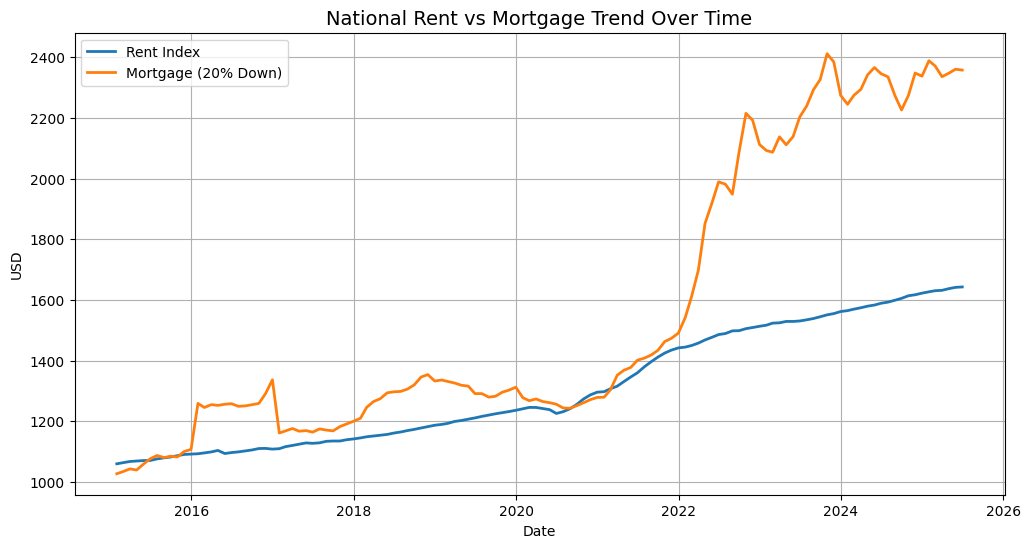

In [15]:
plt.figure(figsize=(12,6))
plt.plot(national_trend.index, national_trend["Rent_Index"], label="Rent Index", linewidth=2)
plt.plot(national_trend.index, national_trend["Monthly_Payment_20Down"], label="Mortgage (20% Down)", linewidth=2)
plt.title("National Rent vs Mortgage Trend Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("USD")
plt.legend()
plt.grid(True)
plt.show()

What the Plot Shows

Early Years (2016–2019):

- Both the Rent Index and Mortgage payment started at a similar level, around $1,000–$1,200 per month.
- The Mortgage line fluctuated more, with a noticeable peak around 2018–2019, while the Rent Index grew steadily but at a slower pace.


Mid-Period (2020–2022):

- Around 2020, the Mortgage payment dropped slightly, possibly due to lower interest rates or economic changes (e.g., pandemic-related mortgage relief).
- After 2020, the Mortgage payment began a sharp upward trend, rising significantly by 2022, reaching around $1,800–$2,000.
- The Rent Index continued to increase steadily, crossing the $1,400 mark by 2022, but it grew more gradually compared to the Mortgage payment.


Later Years (2023–2026):

- The Mortgage payment continued to climb steeply, peaking above $2,200 by 2024 and stabilizing or slightly declining toward $2,400 by 2026.
- The Rent Index kept rising steadily, reaching around $1,600–$1,700 by 2026, but it remained well below the Mortgage payment throughout this period.
- The gap between the two lines widened significantly after 2022, showing that the cost of owning a home grew much faster than the cost of renting.

Key Insight:

The plot indicates that, nationally, the cost of owning a home (mortgage payment with 20% down) has become much higher than the cost of renting over time. By 2026, the Mortgage payment is about $700–$800 more per month than the Rent Index.

In [16]:
latest_date = merged_rent_monthly_payment["Date"].max()
latest_data = merged_rent_monthly_payment[merged_rent_monthly_payment["Date"] == latest_date]
latest_data

,RegionID,RegionName,StateName,SizeRank,Date,Rent_Index,Monthly_Payment_20Down,Rent_Mortgage_ratio,Affordability_gap
48375,394913,"New York, NY",NY,1,2025-06-30,3582.655047,5088.902063,0.704013,1506.247015
48376,753899,"Los Angeles, CA",CA,2,2025-06-30,3011.705830,6188.344484,0.486674,3176.638653
48377,394463,"Chicago, IL",IL,3,2025-06-30,2252.975129,2336.250815,0.964355,83.275686
48378,394514,"Dallas, TX",TX,4,2025-06-30,1793.408573,2734.275492,0.655899,940.866919
48379,394692,"Houston, TX",TX,5,2025-06-30,1733.748285,2262.538239,0.766285,528.789954
...,...,...,...,...,...,...,...,...,...
48757,394787,"Lewiston, ID",ID,518,2025-06-30,2050.000000,2441.193402,0.839753,391.193402
48758,394570,"Enid, OK",OK,523,2025-06-30,1249.067460,1092.797853,1.143000,-156.269607
48759,395199,"Walla Walla, WA",WA,525,2025-06-30,1597.852774,2777.507914,0.575283,1179.655141
48760,394444,"Carson City, NV",NV,551,2025-06-30,2002.125000,3079.697026,0.650105,1077.572026


In [20]:
top_10_cheap_rents = latest_data.sort_values("Rent_Mortgage_ratio", ascending=False).head(10)
top_10_cheap_rents

,RegionID,RegionName,StateName,SizeRank,Date,Rent_Index,Monthly_Payment_20Down,Rent_Mortgage_ratio,Affordability_gap
48703,394635,"Goldsboro, NC",NC,350,2025-06-30,1518.376623,1211.879361,1.252911,-306.497262
48595,394597,"Florence, SC",SC,228,2025-06-30,1496.017725,1227.033489,1.219215,-268.984236
48710,394374,"Beckley, WV",WV,358,2025-06-30,1112.500000,946.499129,1.175384,-166.000871
48673,395139,"Sumter, SC",SC,314,2025-06-30,1492.779630,1281.068002,1.165262,-211.711628
48655,394537,"Dothan, AL",AL,293,2025-06-30,1489.079365,1278.213951,1.164969,-210.865415
48758,394570,"Enid, OK",OK,523,2025-06-30,1249.067460,1092.797853,1.143000,-156.269607
48562,394455,"Charleston, WV",WV,192,2025-06-30,1141.480769,1003.795396,1.137165,-137.685373
48726,394620,"Gadsden, AL",AL,383,2025-06-30,1284.375000,1172.647812,1.095278,-111.727188
48669,394879,"Morgantown, WV",WV,310,2025-06-30,1539.457802,1417.952098,1.085691,-121.505704
48558,395171,"Tuscaloosa, AL",AL,188,2025-06-30,1549.869658,1440.790066,1.075708,-109.079592


In [17]:
top_10_buys_cheap = latest_data.sort_values("Rent_Mortgage_ratio", ascending=True).head(10)
top_10_buys_cheap

,RegionID,RegionName,StateName,SizeRank,Date,Rent_Index,Monthly_Payment_20Down,Rent_Mortgage_ratio,Affordability_gap
48409,395059,"San Jose, CA",CA,36,2025-06-30,3534.563334,10247.174420,0.344931,6712.611086
48707,394867,"Missoula, MT",MT,354,2025-06-30,1550.608205,3800.358428,0.408016,2249.750223
48386,395057,"San Francisco, CA",CA,12,2025-06-30,3215.007392,7437.557297,0.432267,4222.549905
48705,395089,"Sheboygan, WI",WI,352,2025-06-30,992.833333,2192.233583,0.452887,1199.400250
48739,394928,"Ocean City, NJ",NJ,410,2025-06-30,2237.500000,4890.895466,0.457483,2653.395466
48528,394646,"Green Bay, WI",WI,157,2025-06-30,1087.353704,2370.776967,0.458649,1283.423263
48389,395078,"Seattle, WA",WA,15,2025-06-30,2330.061899,5017.512965,0.464386,2687.451066
48718,394804,"Longview, WA",WA,368,2025-06-30,1359.665404,2819.162566,0.482294,1459.497162
48376,753899,"Los Angeles, CA",CA,2,2025-06-30,3011.705830,6188.344484,0.486674,3176.638653
48741,394988,"Pocatello, ID",ID,412,2025-06-30,1087.734599,2231.168714,0.487518,1143.434115


In [21]:
print("Top metros where renting is more expensive than owning:")
print(top_10_cheap_rents[["RegionName", "StateName", "Rent_Mortgage_ratio"]])

Top metros where renting is more expensive than owning:
           RegionName StateName  Rent_Mortgage_ratio
48703   Goldsboro, NC        NC             1.252911
48595    Florence, SC        SC             1.219215
48710     Beckley, WV        WV             1.175384
48673      Sumter, SC        SC             1.165262
48655      Dothan, AL        AL             1.164969
48758        Enid, OK        OK             1.143000
48562  Charleston, WV        WV             1.137165
48726     Gadsden, AL        AL             1.095278
48669  Morgantown, WV        WV             1.085691
48558  Tuscaloosa, AL        AL             1.075708


In [19]:
print("\nTop metros where owning is more expensive than renting:")
print(top_10_buys_cheap[["RegionName", "StateName", "Rent_Mortgage_ratio"]])


Top metros where owning is more expensive than renting:
              RegionName StateName  Rent_Mortgage_ratio
48409       San Jose, CA        CA             0.344931
48707       Missoula, MT        MT             0.408016
48386  San Francisco, CA        CA             0.432267
48705      Sheboygan, WI        WI             0.452887
48739     Ocean City, NJ        NJ             0.457483
48528      Green Bay, WI        WI             0.458649
48389        Seattle, WA        WA             0.464386
48718       Longview, WA        WA             0.482294
48376    Los Angeles, CA        CA             0.486674
48741      Pocatello, ID        ID             0.487518


/tmp/ipykernel_116575/1660814497.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_ratio.sort_values(["Rent_Mortgage_ratio"], ascending=False), x="Rent_Mortgage_ratio", y="StateName", palette="coolwarm")


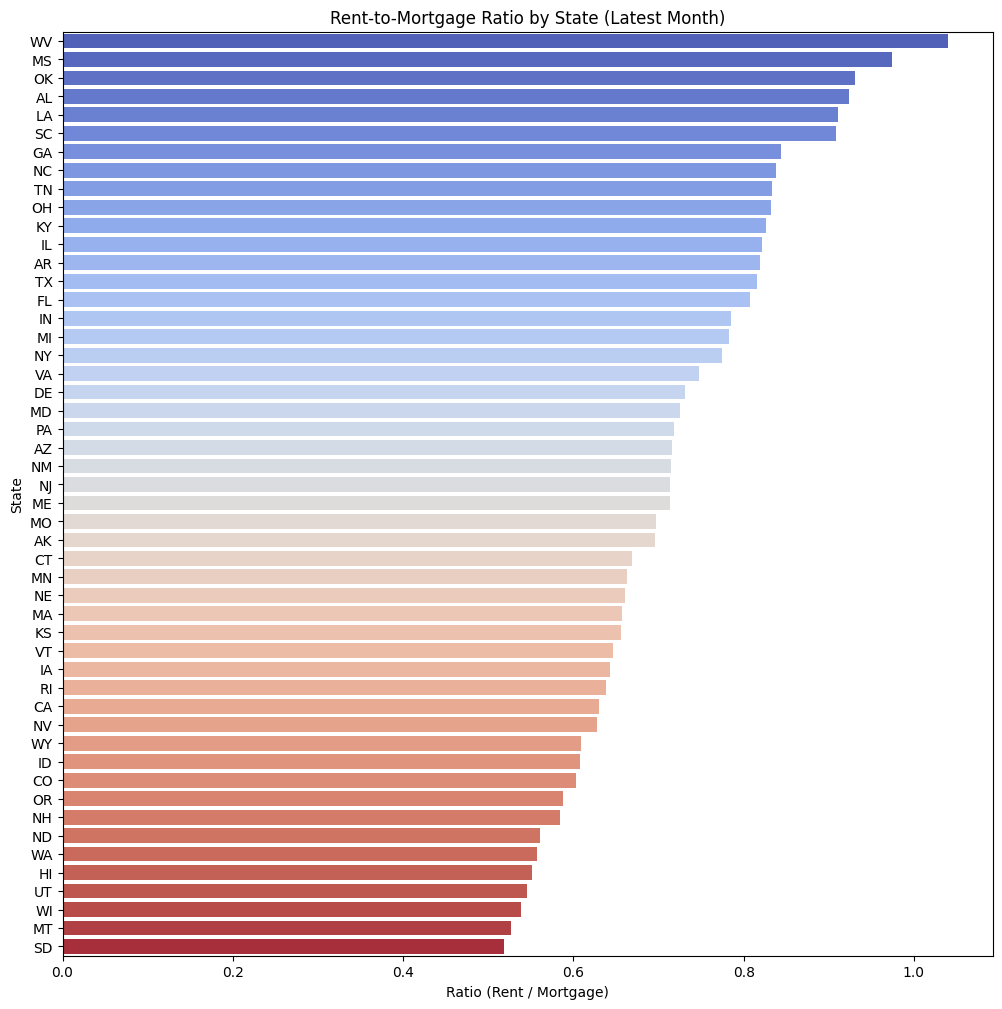

In [22]:
state_ratio = latest_data.groupby("StateName")["Rent_Mortgage_ratio"].mean().reset_index()

plt.figure(figsize=(12,12))
sns.barplot(data=state_ratio.sort_values(["Rent_Mortgage_ratio"], ascending=False), x="Rent_Mortgage_ratio", y="StateName", palette="coolwarm")
plt.title("Rent-to-Mortgage Ratio by State (Latest Month)")
plt.xlabel("Ratio (Rent / Mortgage)")
plt.ylabel("State")
plt.show()

Highest Ratios (Top States):

States like West Virginia (WV), Mississippi (MS), Oklahoma (OK), Louisiana (LA), and Alabama (AL) have the highest ratios, approaching or slightly exceeding 1.0. This suggests that in these states, the cost of renting is nearly as high as (or very close to) the cost of owning a home.

Lowest Ratios (Bottom States):

States like South Dakota (SD), Hawaii (HI), Montana (MT), Wyoming (WY), and California (CA) have the lowest ratios, around 0.2 to 0.4. This indicates that renting is significantly cheaper than owning in these states.

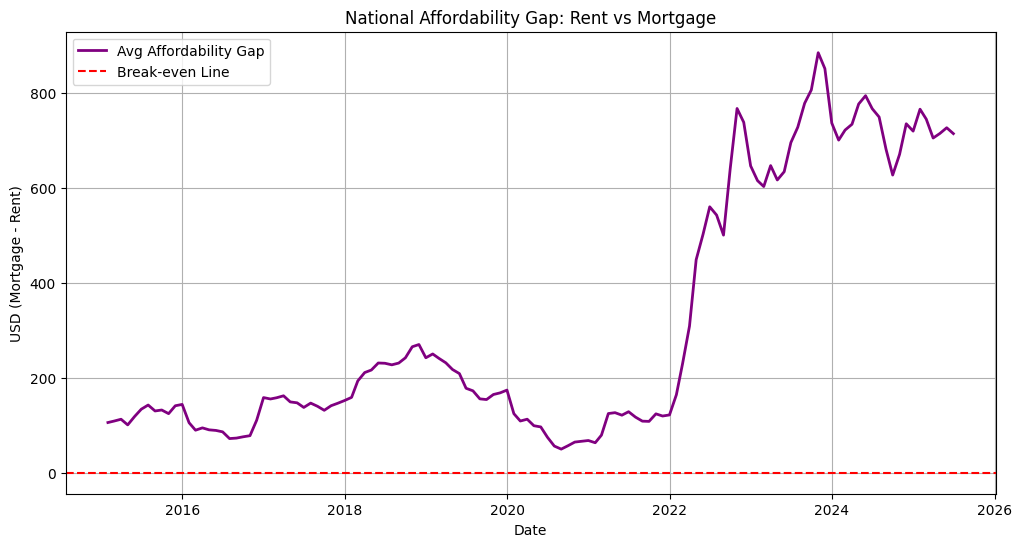

In [23]:
gap_trend = merged_rent_monthly_payment.groupby("Date")["Affordability_gap"].mean()

plt.figure(figsize=(12, 6))
plt.plot(gap_trend.index, gap_trend, label="Avg Affordability Gap", color="purple", linewidth=2)
plt.axhline(0, color="red", linestyle="--", label="Break-even Line")
plt.title("National Affordability Gap: Rent vs Mortgage")
plt.xlabel("Date")
plt.ylabel("USD (Mortgage - Rent)")
plt.legend()
plt.grid(True)
plt.show()

Lines:

- Purple Line (Avg Affordability Gap): Shows the average national affordability gap, calculated as the difference between the monthly mortgage payment (e.g., with 20% down) and the monthly rent (e.g., Zillow’s Observed Rent Index, ZORI).

- Red Dashed Line (Break-even Line): Represents a gap of $0, where the cost of renting equals the cost of owning. Values above this line indicate owning is more expensive; values below would indicate renting is more expensive.